## 1. Import Required Libraries

In [11]:
# Data manipulation
import pandas as pd
import numpy as np

# Data source
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistics
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")

## 2. Download Historical Data

In [12]:
start_date = "2015-01-01"
end_date = "2026-06-30"

tickers = ["TSLA", "BND", "SPY"]

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )
    df["Ticker"] = ticker
    data[ticker] = df

print("Downloaded Successfully!")

Downloaded Successfully!


### View Sample Data

In [13]:
data

{'TSLA': Price        Adj Close       Close        High         Low        Open  \
 Ticker            TSLA        TSLA        TSLA        TSLA        TSLA   
 Date                                                                     
 2015-01-02   14.620667   14.620667   14.883333   14.217333   14.858000   
 2015-01-05   14.006000   14.006000   14.433333   13.810667   14.303333   
 2015-01-06   14.085333   14.085333   14.280000   13.614000   14.004000   
 2015-01-07   14.063333   14.063333   14.318667   13.985333   14.223333   
 2015-01-08   14.041333   14.041333   14.253333   14.000667   14.187333   
 ...                ...         ...         ...         ...         ...   
 2026-06-23  381.609985  381.609985  392.869995  379.059998  392.609985   
 2026-06-24  375.529999  375.529999  384.579987  373.049988  380.079987   
 2026-06-25  375.119995  375.119995  379.119995  371.220001  375.269989   
 2026-06-26  379.709991  379.709991  387.799988  368.600006  370.149994   
 2026-06-29  411.

## 3. Basic Data Inspection

In [14]:
for ticker, df in data.items():

    print("="*60)
    print(f"{ticker}")
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nSummary Statistics:")
    print(df.describe())

TSLA

Shape:
(2888, 7)

Data Types:
Price      Ticker
Adj Close  TSLA      float64
Close      TSLA      float64
High       TSLA      float64
Low        TSLA      float64
Open       TSLA      float64
Volume     TSLA        int64
Ticker                object
dtype: object

Missing Values:
Price      Ticker
Adj Close  TSLA      0
Close      TSLA      0
High       TSLA      0
Low        TSLA      0
Open       TSLA      0
Volume     TSLA      0
Ticker               0
dtype: int64

Summary Statistics:
Price     Adj Close        Close         High          Low         Open  \
Ticker         TSLA         TSLA         TSLA         TSLA         TSLA   
count   2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean     148.773923   148.773923   151.990563   145.416731   148.797341   
std      138.895957   138.895957   141.852818   135.867193   138.977191   
min        9.578000     9.578000    10.331333     9.403333     9.488000   
25%       18.393499    18.393499    18.665168    

## 4. Data Cleaning

### Convert Index to Datetime

In [15]:
for ticker in tickers:
    data[ticker].index = pd.to_datetime(data[ticker].index)

## Handle Missing Values

In [16]:
for ticker in tickers:

    data[ticker] = data[ticker].ffill()
    data[ticker] = data[ticker].bfill()

    print(f"{ticker} Missing Values")
    print(data[ticker].isnull().sum())

TSLA Missing Values
Price      Ticker
Adj Close  TSLA      0
Close      TSLA      0
High       TSLA      0
Low        TSLA      0
Open       TSLA      0
Volume     TSLA      0
Ticker               0
dtype: int64
BND Missing Values
Price      Ticker
Adj Close  BND       0
Close      BND       0
High       BND       0
Low        BND       0
Open       BND       0
Volume     BND       0
Ticker               0
dtype: int64
SPY Missing Values
Price      Ticker
Adj Close  SPY       0
Close      SPY       0
High       SPY       0
Low        SPY       0
Open       SPY       0
Volume     SPY       0
Ticker               0
dtype: int64


## Check Duplicate Rows

In [17]:
for ticker in tickers:

    duplicates = data[ticker].duplicated().sum()

    print(ticker, duplicates)

TSLA 0
BND 0
SPY 0


## 5. Feature Engineering

### Daily Returns

In [18]:
for ticker in tickers:

    data[ticker]["Daily Return"] = data[ticker]["Adj Close"].pct_change()

    data[ticker]["Daily Return"].fillna(0, inplace=True)

### Rolling Mean

In [19]:
for ticker in tickers:

    data[ticker]["Rolling Mean"] = data[ticker]["Adj Close"].rolling(20).mean()

    data[ticker]["Rolling Std"] = data[ticker]["Adj Close"].rolling(20).std()

## 6. Normalization

In [20]:
scaler = MinMaxScaler()

scaled_data = {}

for ticker in tickers:

    scaled = scaler.fit_transform(
        data[ticker][["Adj Close"]]
    )

    scaled_data[ticker] = scaled

## 7. Exploratory Data Analysis

### Visualization 1: Closing Price

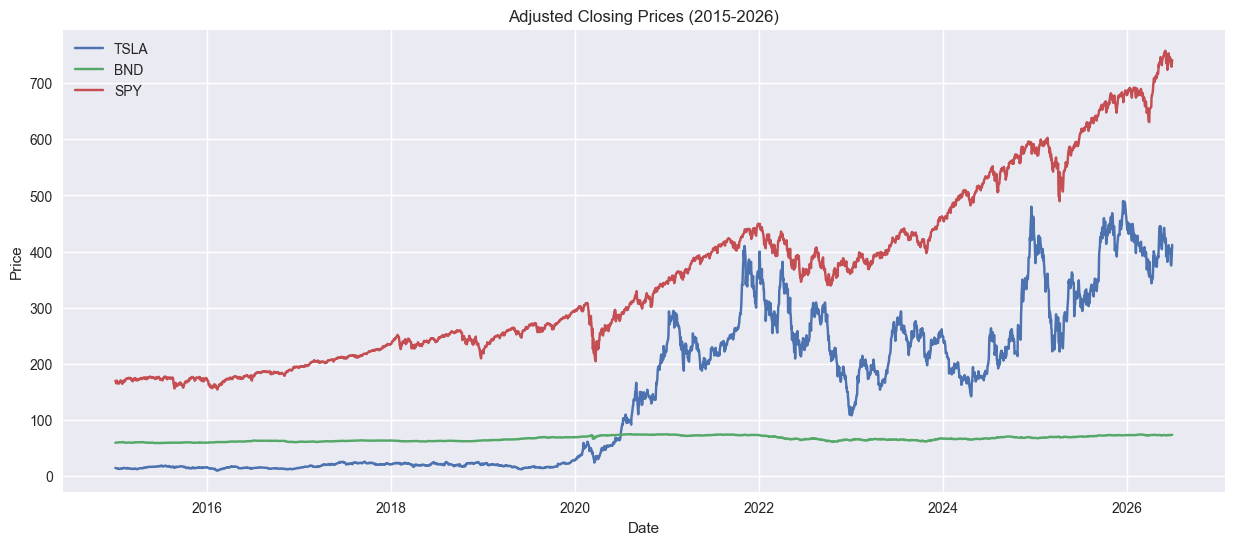

In [21]:
plt.figure(figsize=(15,6))

for ticker in tickers:

    plt.plot(
        data[ticker].index,
        data[ticker]["Adj Close"],
        label=ticker
    )

plt.title("Adjusted Closing Prices (2015-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Visualization 2: Daily Returns

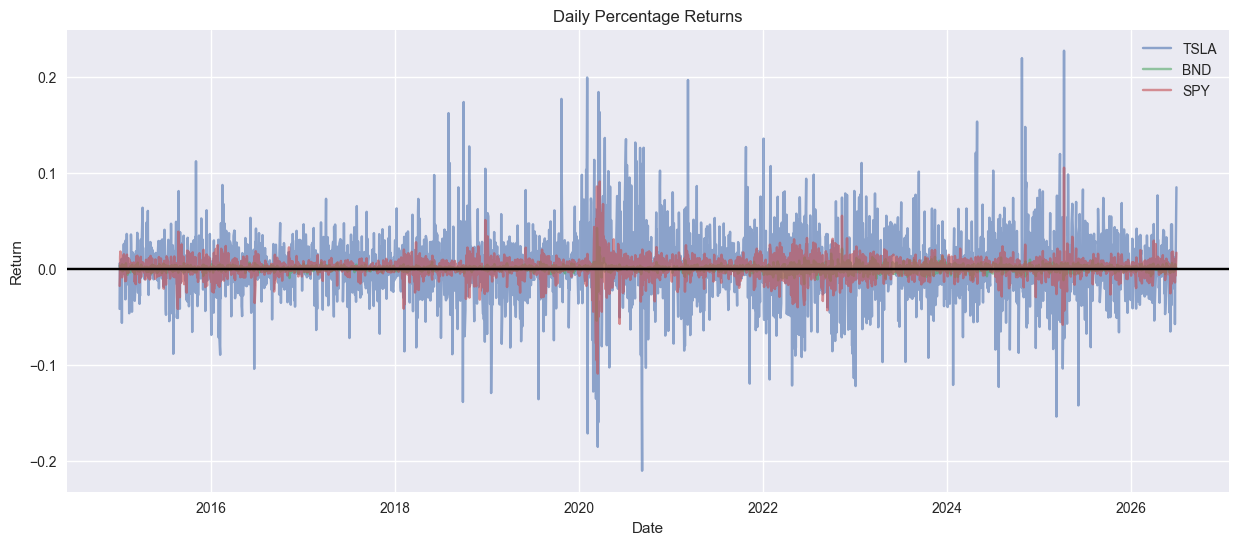

In [22]:
plt.figure(figsize=(15,6))

for ticker in tickers:

    plt.plot(
        data[ticker].index,
        data[ticker]["Daily Return"],
        alpha=0.6,
        label=ticker
    )

plt.axhline(0,color='black')

plt.title("Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()

plt.show()

### Visualization 3: Rolling Mean and Volatility

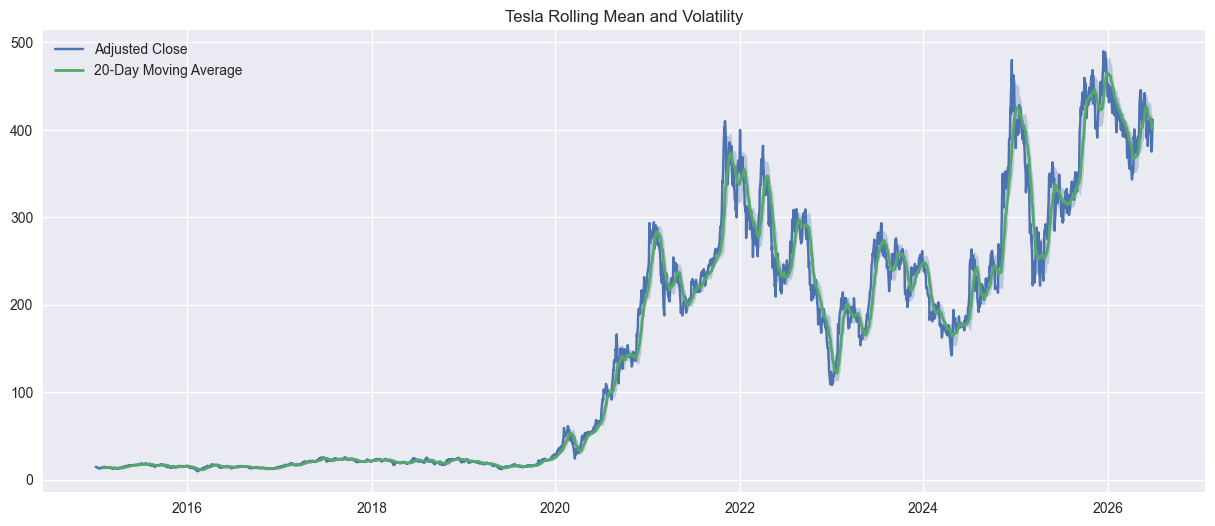

In [23]:
plt.figure(figsize=(15,6))

plt.plot(
    data["TSLA"]["Adj Close"],
    label="Adjusted Close"
)

plt.plot(
    data["TSLA"]["Rolling Mean"],
    label="20-Day Moving Average",
    linewidth=2
)

plt.fill_between(
    data["TSLA"].index,
    data["TSLA"]["Rolling Mean"]-data["TSLA"]["Rolling Std"],
    data["TSLA"]["Rolling Mean"]+data["TSLA"]["Rolling Std"],
    alpha=0.3
)

plt.legend()

plt.title("Tesla Rolling Mean and Volatility")

plt.show()

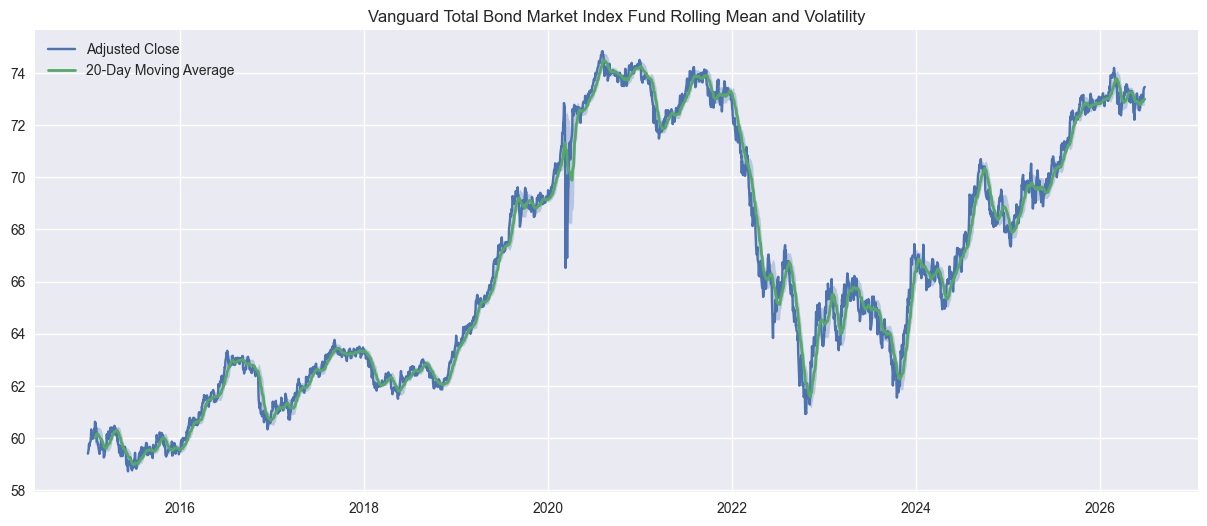

In [24]:
plt.figure(figsize=(15,6))

plt.plot(
    data["BND"]["Adj Close"],
    label="Adjusted Close"
)

plt.plot(
    data["BND"]["Rolling Mean"],
    label="20-Day Moving Average",
    linewidth=2
)

plt.fill_between(
    data["BND"].index,
    data["BND"]["Rolling Mean"]-data["BND"]["Rolling Std"],
    data["BND"]["Rolling Mean"]+data["BND"]["Rolling Std"],
    alpha=0.3
)

plt.legend()

plt.title("Vanguard Total Bond Market Index Fund Rolling Mean and Volatility")

plt.show()

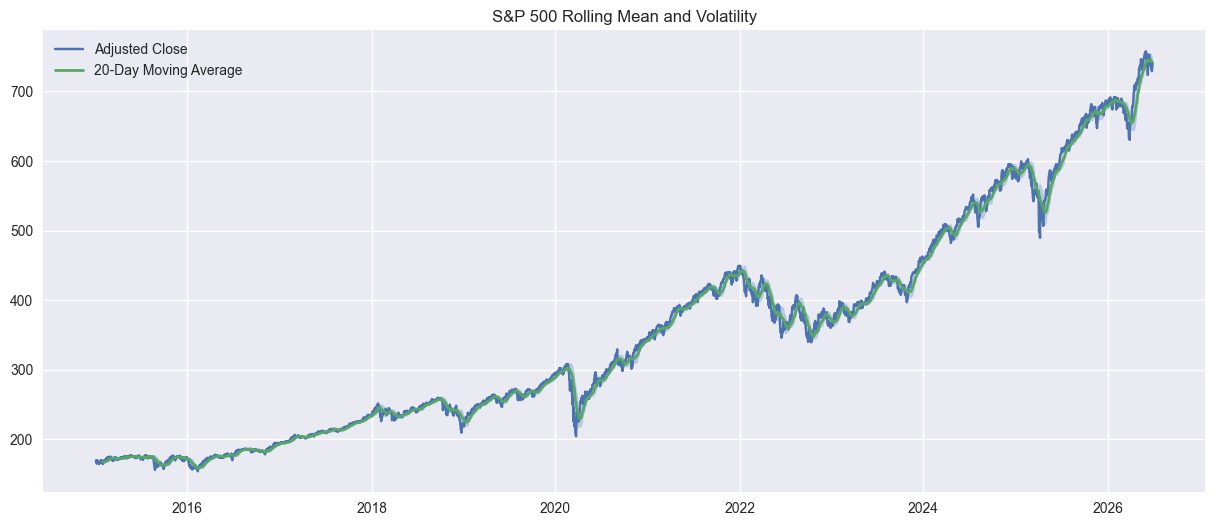

In [25]:
plt.figure(figsize=(15,6))

plt.plot(
    data["SPY"]["Adj Close"],
    label="Adjusted Close"
)

plt.plot(
    data["SPY"]["Rolling Mean"],
    label="20-Day Moving Average",
    linewidth=2
)

plt.fill_between(
    data["SPY"].index,
    data["SPY"]["Rolling Mean"]-data["SPY"]["Rolling Std"],
    data["SPY"]["Rolling Mean"]+data["SPY"]["Rolling Std"],
    alpha=0.3
)

plt.legend()

plt.title("S&P 500 Rolling Mean and Volatility")

plt.show()

## Visualization 4: Distribution of Daily Returns

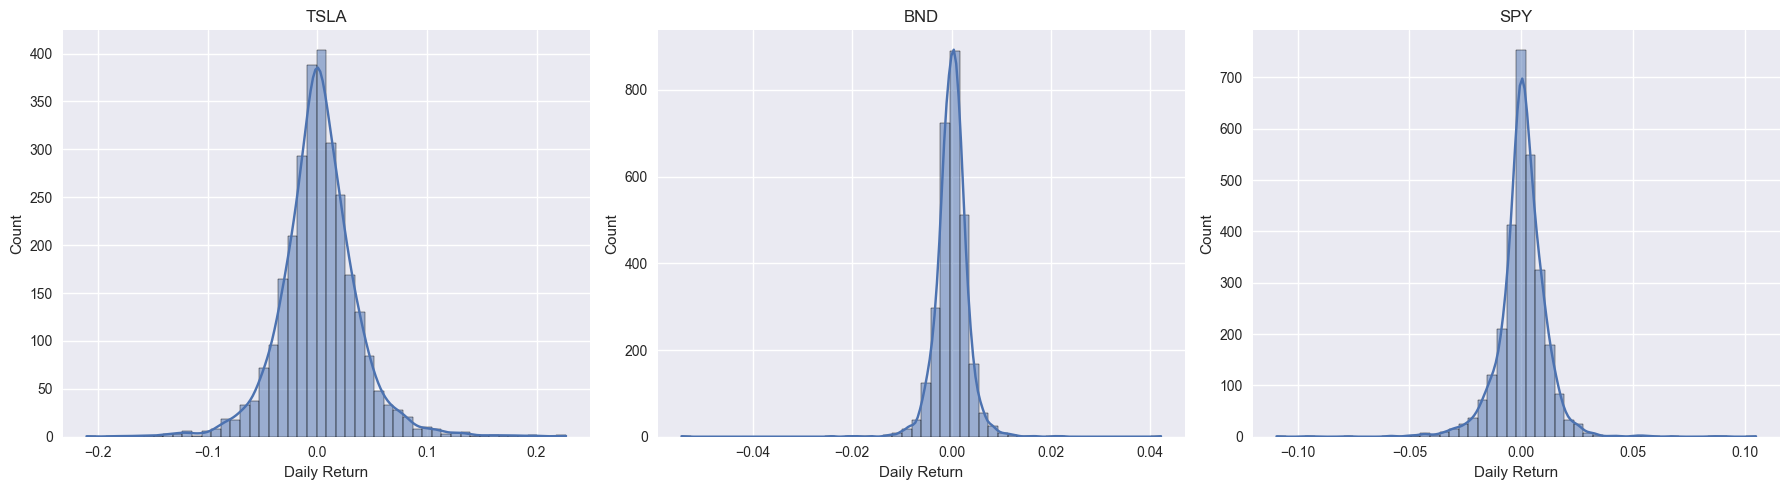

In [26]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for ax, ticker in zip(axes, tickers):

    sns.histplot(
        data[ticker]["Daily Return"],
        bins=50,
        kde=True,
        ax=ax
    )

    ax.set_title(ticker)

plt.tight_layout()

plt.show()

## 8. Outlier Detection

In [27]:
for ticker in tickers:

    returns = data[ticker]["Daily Return"]

    z_scores = np.abs(stats.zscore(returns))

    outliers = returns[z_scores > 3]

    print(f"{ticker}")

    print("Number of Outliers:",len(outliers))

    print(outliers.head())

    print()

TSLA
Number of Outliers: 0
Series([], Name: Daily Return, dtype: float64)

BND
Number of Outliers: 0
Series([], Name: Daily Return, dtype: float64)

SPY
Number of Outliers: 0
Series([], Name: Daily Return, dtype: float64)



## 9. Stationarity Analysis

### Augmented Dickey-Fuller Test

In [28]:
def adf_test(series):

    result = adfuller(series.dropna())

    print("ADF Statistic:", result[0])

    print("P-value:", result[1])

    print("Critical Values")

    for key,value in result[4].items():

        print(key, value)

    if result[1] < 0.05:

        print("Stationary")

    else:

        print("Non-Stationary")

### Closing Prices

In [29]:
for ticker in tickers:

    print("="*50)

    print(ticker)

    adf_test(data[ticker]["Adj Close"])

TSLA
ADF Statistic: -1.069599139417746
P-value: 0.7270419411549222
Critical Values
1% -3.432638524105552
5% -2.8625511137463935
10% -2.567308245513228
Non-Stationary
BND
ADF Statistic: -1.0827078222967466
P-value: 0.7219183340511365
Critical Values
1% -3.432627366129768
5% -2.862546185823105
10% -2.567305621914905
Non-Stationary
SPY
ADF Statistic: 1.3089446163497571
P-value: 0.996658550851699
Critical Values
1% -3.4326241980933294
5% -2.8625447866555227
10% -2.567304877006608
Non-Stationary


### Daily Returns

In [30]:
for ticker in tickers:

    print("="*50)

    print(ticker)

    adf_test(data[ticker]["Daily Return"])

TSLA
ADF Statistic: -53.971892804251446
P-value: 0.0
Critical Values
1% -3.4326178883893763
5% -2.862541999961805
10% -2.567303393388591
Stationary
BND
ADF Statistic: -15.216126722335868
P-value: 5.56731655525773e-28
Critical Values
1% -3.432627366129768
5% -2.862546185823105
10% -2.567305621914905
Stationary
SPY
ADF Statistic: -17.57218340934384
P-value: 4.04629811565814e-30
Critical Values
1% -3.4326241980933294
5% -2.8625447866555227
10% -2.567304877006608
Stationary


## 10. Risk Metrics


### Value at Risk (95%)

In [31]:
confidence = 0.05

for ticker in tickers:

    returns = data[ticker]["Daily Return"]

    var = np.percentile(returns,100*confidence)

    print(f"{ticker} VaR (95%): {var:.4f}")

TSLA VaR (95%): nan
BND VaR (95%): nan
SPY VaR (95%): nan


### Sharpe Ratio

In [32]:
risk_free = 0.02

daily_rf = risk_free/252

for ticker in tickers:

    returns = data[ticker]["Daily Return"]

    sharpe = np.sqrt(252) * (
        (returns.mean()-daily_rf)
        /returns.std()
    )

    print(f"{ticker} Sharpe Ratio: {sharpe:.2f}")

TSLA Sharpe Ratio: 0.76
BND Sharpe Ratio: -0.00
SPY Sharpe Ratio: 0.70


## Save the cleaned data

In [ ]:
data["BND"].to_csv("../data/processed/BND_cleaned.csv")
data["SPY"].to_csv("../data/processed/SPY_cleaned.csv")
tsla = data["TSLA"].copy()

# Remove the second level (TSLA)
tsla.columns = tsla.columns.get_level_values(0)

tsla.to_csv("../data/processed/TSLA_cleaned.csv")